#World Cup 2026 Predictor

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")

print("Path to dataset files:", path)

100%|██████████| 1.21M/1.21M [00:00<00:00, 106MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/121


In [3]:
import pandas as pd
import os

results_file_path = os.path.join(path, 'results.csv')
results = pd.read_csv(results_file_path)

# Display the first few rows of the DataFrame to verify
display(results.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### Data Trimming

We will keep only results from the beginning of the last world cup to the present.
We will keep results only from the countries taking part in this WC

In [4]:
results['date'] = pd.to_datetime(results['date'])

# Filter out results from before November 19, 2022
filtered_results = results[results['date'] >= '2022-11-19'].copy()

display(filtered_results.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
45686,2022-11-19,Albania,Armenia,2.0,0.0,Friendly,Tirana,Albania,False
45687,2022-11-19,Colombia,Paraguay,2.0,0.0,Friendly,Fort Lauderdale,United States,True
45688,2022-11-19,Gibraltar,Andorra,1.0,0.0,Friendly,Gibraltar,Gibraltar,False
45689,2022-11-19,Guatemala,Nicaragua,3.0,1.0,Friendly,Carson,United States,True
45690,2022-11-19,Ivory Coast,Burkina Faso,1.0,2.0,Friendly,Marrakesh,Morocco,True


In [5]:
# List of World Cup participating countries
world_cup_countries = [
    "Mexico", "South Africa", "South Korea", "Czechia",
    "Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland",
    "Brazil", "Morocco", "Haiti", "Scotland",
    "United States", "Paraguay", "Australia", "Turkey",
    "Germany", "Curacao", "Ivory Coast", "Ecuador",
    "Netherlands", "Japan", "Sweden", "Tunisia",
    "Belgium", "Egypt", "Iran", "New Zealand",
    "Spain", "Cape Verde", "Saudi Arabia", "Uruguay",
    "France", "Senegal", "Iraq", "Norway",
    "Argentina", "Algeria", "Austria", "Jordan",
    "Portugal", "DR Congo", "Uzbekistan", "Colombia",
    "England", "Croatia", "Ghana", "Panama"
]

# Filter the dataframe to keep only matches involving these countries
# A match is kept if either the home_team or the away_team is in the world_cup_countries list
world_cup_results = filtered_results[
    (filtered_results['home_team'].isin(world_cup_countries)) |
    (filtered_results['away_team'].isin(world_cup_countries))
].copy()

display(world_cup_results.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
45687,2022-11-19,Colombia,Paraguay,2.0,0.0,Friendly,Fort Lauderdale,United States,True
45690,2022-11-19,Ivory Coast,Burkina Faso,1.0,2.0,Friendly,Marrakesh,Morocco,True
45695,2022-11-19,Sweden,Algeria,2.0,0.0,Friendly,Malmö,Sweden,False
45696,2022-11-19,Turkey,Czech Republic,2.0,1.0,Friendly,Gaziantep,Turkey,False
45700,2022-11-20,Austria,Italy,2.0,0.0,Friendly,Vienna,Austria,False


## Understanding the dataset

### Visualize Wins, Ties, and Losses per Country

Let's calculate the wins, ties, and losses for each country in our `world_cup_results` dataset and then visualize this using a stacked bar graph.

In [6]:
from collections import defaultdict

# Initialize dictionaries to store counts
country_stats = defaultdict(lambda: {'wins': 0, 'ties': 0, 'losses': 0})

# Iterate through each match to update statistics
for index, row in world_cup_results.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    home_score = row['home_score']
    away_score = row['away_score']

    # Ensure both teams are in the world_cup_countries list before counting
    # This is to make sure only head-to-head WC relevant matches are counted for stats
    if home_team in world_cup_countries and away_team in world_cup_countries:
        if home_score > away_score:
            country_stats[home_team]['wins'] += 1
            country_stats[away_team]['losses'] += 1
        elif away_score > home_score:
            country_stats[away_team]['wins'] += 1
            country_stats[home_team]['losses'] += 1
        else:
            country_stats[home_team]['ties'] += 1
            country_stats[away_team]['ties'] += 1

# Convert the dictionary to a DataFrame for easier plotting
stats_df = pd.DataFrame.from_dict(country_stats, orient='index')
stats_df.index.name = 'country'
stats_df = stats_df.reset_index()

display(stats_df.head())

,country,wins,ties,losses
0,Colombia,17,11,6
1,Paraguay,5,7,10
2,Sweden,3,4,7
3,Algeria,6,7,2
4,Ecuador,7,15,5


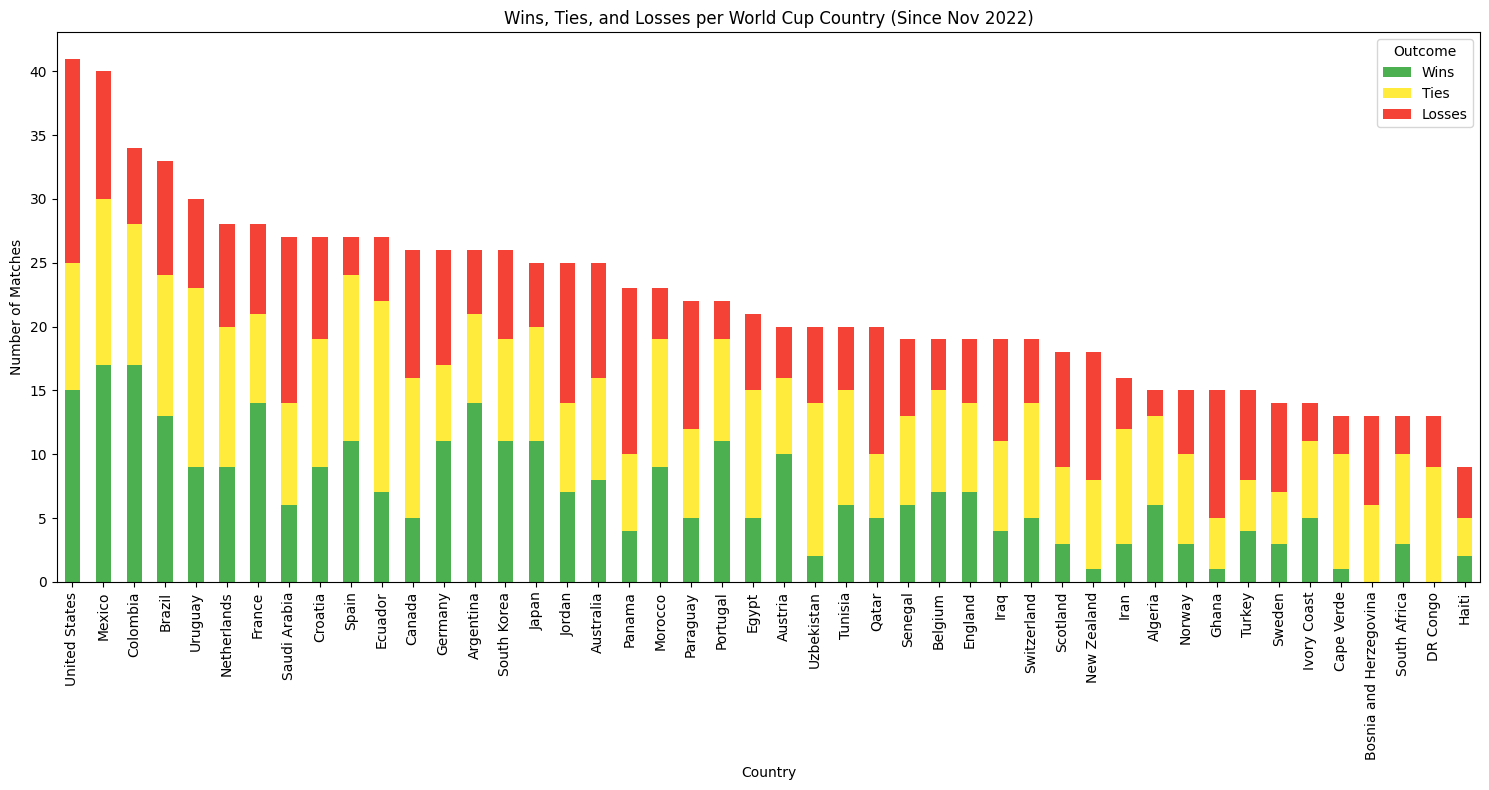

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by total games or wins for better visualization if desired
# For now, let's sort by total wins
stats_df['total_games'] = stats_df['wins'] + stats_df['ties'] + stats_df['losses']
stats_df = stats_df.sort_values(by='total_games', ascending=False)

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(15, 8))

stats_df.set_index('country')[['wins', 'ties', 'losses']].plot(kind='bar', stacked=True,
                                                                    color=['#4CAF50', '#FFEB3B', '#F44336'],
                                                                    ax=ax)

ax.set_title('Wins, Ties, and Losses per World Cup Country (Since Nov 2022)')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Matches')
ax.legend(['Wins', 'Ties', 'Losses'], title='Outcome')
ax.tick_params(axis='x', rotation=90) # Rotate x-axis labels for readability

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

##First Approach: ELO ratings
We will calculate ELO ratings to predict win/tie/lose outcomes.
Then we will compare the calculated ELO´s with the Fifa ratings.

In [8]:
import math

# Initialize ELO ratings for all World Cup countries
elo_ratings = {country: 1500 for country in world_cup_countries}

# ELO parameters
K = 30 # K-factor for rating changes

def calculate_win_probability(team1_elo, team2_elo):
    """Calculates the probability of team1 winning against team2."""
    return 1 / (1 + math.pow(10, (team2_elo - team1_elo) / 400))

def update_elo(team1_elo, team2_elo, outcome, K):
    """Updates ELO ratings based on match outcome.
    Outcome: 1 for team1 win, 0.5 for draw, 0 for team1 loss.
    """
    expected_team1 = calculate_win_probability(team1_elo, team2_elo)

    new_team1_elo = team1_elo + K * (outcome - expected_team1)
    new_team2_elo = team2_elo + K * ((1 - outcome) - (1 - expected_team1))

    return new_team1_elo, new_team2_elo

# Process each match in chronological order to update ELO ratings
# Ensure the dataframe is sorted by date for correct ELO progression
world_cup_results_sorted = world_cup_results.sort_values(by='date').copy()

for index, row in world_cup_results_sorted.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    home_score = row['home_score']
    away_score = row['away_score']

    # Only update ELO if both teams are in our considered world_cup_countries
    if home_team in elo_ratings and away_team in elo_ratings:
        home_elo = elo_ratings[home_team]
        away_elo = elo_ratings[away_team]

        if home_score > away_score:
            outcome_home = 1    # Home team wins
        elif away_score > home_score:
            outcome_home = 0    # Home team loses
        else:
            outcome_home = 0.5  # Draw

        new_home_elo, new_away_elo = update_elo(home_elo, away_elo, outcome_home, K)

        elo_ratings[home_team] = new_home_elo
        elo_ratings[away_team] = new_away_elo

# Convert the final ELO ratings to a DataFrame
countries_elo = pd.DataFrame.from_dict(elo_ratings, orient='index', columns=['elo_rating'])
countries_elo.index.name = 'country'

# Display the DataFrame in descending order of ELO rating
display(countries_elo.sort_values(by='elo_rating', ascending=False).head(10))

,elo_rating
country,
Argentina,1579.453709
Portugal,1578.424457
Spain,1575.524110
Colombia,1571.183374
France,1565.040067
Mexico,1563.072275
Austria,1561.238877
Brazil,1560.286141
Algeria,1550.157984


### Merge with Historic ELO Ratings

Now, let's download the historic ELO ratings and merge them with our calculated 'since last WC' ELO ratings. We will filter the historic data to only include World Cup participating countries.

In [9]:
# Download the historic ELO ratings dataset
elo_path = kagglehub.dataset_download("saifalnimri/international-football-elo-ratings")

# Construct the path to eloratings.csv
eloratings_file_path = os.path.join(elo_path, 'eloratings.csv')

# Load the eloratings.csv into a DataFrame
eloratings_df = pd.read_csv(eloratings_file_path)
display(eloratings_df.head())

Using Colab cache for faster access to the 'international-football-elo-ratings' dataset.


,date,team,rating,change
0,1872-11-30,England,2003.0,3
1,1872-11-30,Scotland,1997.0,-3
2,1873-03-08,England,2014.0,11
3,1873-03-08,Scotland,1986.0,-11
4,1874-03-07,England,2006.0,-8


In [15]:
# Filter historic ELO ratings to keep only countries taking part in the WC
# Correcting 'country' to 'team' for filtering
filtered_eloratings_df = eloratings_df[eloratings_df['team'].isin(world_cup_countries)].copy()

# Rename columns for clarity: 'team' to 'country' and 'rating': 'historic' in the historic ELO dataframe
historic_elo_renamed = filtered_eloratings_df.rename(columns={'team': 'country', 'rating': 'historic'})

# Convert date column to datetime for proper sorting, using 'mixed' format to handle inconsistencies
historic_elo_renamed['date'] = pd.to_datetime(historic_elo_renamed['date'], format='mixed')

# Get the latest ELO rating for each country from the historic data
latest_historic_elo = historic_elo_renamed.sort_values(by='date', ascending=True).groupby('country').last().reset_index()

# Rename columns for clarity in countries_elo (our calculated ELO)
countries_elo_renamed = countries_elo.rename(columns={'elo_rating': 'since last WC'})

# Set 'country' as index for the historic DataFrame for merging
latest_historic_elo = latest_historic_elo.set_index('country')

# Merge the two DataFrames. Ensure we only merge the 'historic' column from the historic data.
merged_elo_df = countries_elo_renamed.merge(latest_historic_elo[['historic']], left_index=True, right_index=True, how='inner')

# Display the merged DataFrame in descending order of 'since last WC' ELO
display(merged_elo_df.sort_values(by='since last WC', ascending=False))

,since last WC,historic
country,,
Argentina,1579.453709,2113.0
Portugal,1578.424457,1976.0
Spain,1575.524110,2171.0
Colombia,1571.183374,1998.0
France,1565.040067,2062.0
Mexico,1563.072275,1835.0
Austria,1561.238877,1818.0
Brazil,1560.286141,1979.0
Algeria,1550.157984,1726.0


### Calculate Win Probability Matrix

Now, let's calculate the win probability between each pair of World Cup countries based on their 'since last WC' ELO ratings. The results will be displayed in a matrix with a color gradient from red (0) to green (1), indicating the probability of the row team winning against the column team.

In [26]:
import numpy as np

# countries_elo is already indexed by 'country' from previous steps
# So we can use it directly, or make a copy if further modifications to the index are expected
# For this calculation, direct use is fine as we are only reading values.

# Get a sorted list of all unique countries that are in our ELO calculation
all_countries_sorted = sorted(countries_elo.index.tolist())

# Initialize a DataFrame to store win probabilities
win_probability_matrix = pd.DataFrame(index=all_countries_sorted, columns=all_countries_sorted, dtype=float)

# Populate the matrix
for home_country in all_countries_sorted:
    for away_country in all_countries_sorted:
        if home_country == away_country:
            win_probability_matrix.loc[home_country, away_country] = np.nan # No probability against self
        else:
            home_elo = countries_elo.loc[home_country, 'elo_rating']
            away_elo = countries_elo.loc[away_country, 'elo_rating']
            win_prob = calculate_win_probability(home_elo, away_elo)
            win_probability_matrix.loc[home_country, away_country] = win_prob

# Display the formatted matrix
# Using a custom function for background gradient
def color_gradient(val):
    if pd.isna(val):
        return '' # No color for NaN (diagonal)
    r = 255 if val < 0.5 else int(255 - (val - 0.5) * 510) # Red decreases from 255 to 0
    g = 255 if val > 0.5 else int(255 - (0.5 - val) * 510) # Green increases from 0 to 255
    return f'background-color: rgb({r},{g},0)'

# Apply the styling and format to two decimal places
styled_matrix = win_probability_matrix.style.format('{:.2f}', na_rep='-').map(color_gradient, subset=pd.IndexSlice[all_countries_sorted, all_countries_sorted])

display(styled_matrix)

,Algeria,Argentina,Australia,Austria,Belgium,Bosnia and Herzegovina,Brazil,Canada,Cape Verde,Colombia,Croatia,Curacao,Czechia,DR Congo,Ecuador,Egypt,England,France,Germany,Ghana,Haiti,Iran,Iraq,Ivory Coast,Japan,Jordan,Mexico,Morocco,Netherlands,New Zealand,Norway,Panama,Paraguay,Portugal,Qatar,Saudi Arabia,Scotland,Senegal,South Africa,South Korea,Spain,Sweden,Switzerland,Tunisia,Turkey,United States,Uruguay,Uzbekistan
Algeria,-,0.46,0.58,0.48,0.52,0.67,0.49,0.60,0.60,0.47,0.57,0.57,0.57,0.62,0.51,0.59,0.57,0.48,0.51,0.70,0.61,0.60,0.63,0.53,0.51,0.62,0.48,0.50,0.56,0.69,0.59,0.67,0.62,0.46,0.63,0.67,0.65,0.58,0.59,0.53,0.46,0.63,0.56,0.57,0.60,0.58,0.55,0.63
Argentina,0.54,-,0.62,0.53,0.57,0.71,0.53,0.64,0.64,0.51,0.61,0.61,0.61,0.66,0.56,0.63,0.61,0.52,0.55,0.73,0.65,0.64,0.67,0.57,0.55,0.66,0.52,0.54,0.60,0.73,0.63,0.71,0.66,0.50,0.67,0.70,0.68,0.62,0.63,0.57,0.51,0.67,0.61,0.61,0.64,0.62,0.59,0.66
Australia,0.42,0.38,-,0.40,0.44,0.59,0.40,0.52,0.52,0.39,0.49,0.49,0.49,0.54,0.43,0.51,0.48,0.40,0.43,0.63,0.53,0.52,0.55,0.45,0.42,0.54,0.40,0.42,0.47,0.62,0.51,0.60,0.54,0.38,0.56,0.59,0.57,0.50,0.51,0.44,0.38,0.55,0.48,0.48,0.52,0.50,0.47,0.55
Austria,0.52,0.47,0.60,-,0.54,0.69,0.50,0.62,0.62,0.49,0.59,0.59,0.59,0.64,0.53,0.60,0.58,0.49,0.53,0.71,0.63,0.62,0.65,0.54,0.52,0.63,0.50,0.52,0.57,0.71,0.61,0.69,0.64,0.48,0.65,0.68,0.66,0.60,0.61,0.54,0.48,0.65,0.58,0.58,0.62,0.59,0.57,0.64
Belgium,0.48,0.43,0.56,0.46,-,0.65,0.46,0.58,0.58,0.45,0.55,0.55,0.55,0.60,0.49,0.57,0.54,0.45,0.48,0.68,0.59,0.58,0.61,0.50,0.48,0.60,0.46,0.48,0.53,0.67,0.57,0.65,0.60,0.44,0.61,0.64,0.62,0.56,0.57,0.50,0.44,0.61,0.54,0.54,0.58,0.56,0.53,0.60
Bosnia and Herzegovina,0.33,0.29,0.41,0.31,0.35,-,0.32,0.42,0.42,0.30,0.40,0.40,0.40,0.45,0.34,0.41,0.39,0.31,0.34,0.53,0.43,0.42,0.46,0.36,0.33,0.44,0.31,0.33,0.38,0.53,0.42,0.50,0.45,0.29,0.46,0.49,0.47,0.41,0.42,0.35,0.30,0.46,0.39,0.39,0.43,0.40,0.38,0.45
Brazil,0.51,0.47,0.60,0.50,0.54,0.68,-,0.61,0.61,0.48,0.59,0.59,0.59,0.64,0.53,0.60,0.58,0.49,0.52,0.71,0.62,0.61,0.65,0.54,0.52,0.63,0.50,0.51,0.57,0.71,0.61,0.69,0.63,0.47,0.65,0.68,0.66,0.60,0.61,0.54,0.48,0.65,0.58,0.58,0.62,0.59,0.56,0.64
Canada,0.40,0.36,0.48,0.38,0.42,0.58,0.39,-,0.50,0.37,0.47,0.47,0.47,0.52,0.41,0.49,0.46,0.38,0.41,0.61,0.51,0.50,0.53,0.43,0.41,0.52,0.38,0.40,0.45,0.60,0.49,0.58,0.52,0.36,0.54,0.57,0.55,0.48,0.49,0.42,0.37,0.53,0.46,0.46,0.50,0.48,0.45,0.53
Cape Verde,0.40,0.36,0.48,0.38,0.42,0.58,0.39,0.50,-,0.37,0.47,0.47,0.47,0.52,0.41,0.49,0.46,0.38,0.41,0.61,0.51,0.50,0.53,0.43,0.41,0.52,0.38,0.40,0.45,0.60,0.49,0.58,0.52,0.36,0.54,0.57,0.55,0.48,0.49,0.42,0.36,0.53,0.46,0.46,0.50,0.48,0.45,0.53
Colombia,0.53,0.49,0.61,0.51,0.55,0.70,0.52,0.63,0.63,-,0.60,0.60,0.60,0.65,0.54,0.62,0.59,0.51,0.54,0.72,0.64,0.63,0.66,0.56,0.54,0.65,0.51,0.53,0.58,0.72,0.62,0.70,0.65,0.49,0.66,0.69,0.67,0.61,0.62,0.56,0.49,0.66,0.59,0.59,0.63,0.61,0.58,0.65


### Calculate Win Probability Matrix (Historic ELO)

Now, let's calculate the win probability between each pair of World Cup countries based on their *historic* ELO ratings. This provides a long-term perspective on their relative strengths. The results will be displayed in a matrix with a color gradient from red (0) to green (1).

In [27]:
import numpy as np

# Ensure merged_elo_df is ready. It already has 'country' as index.

# Get a sorted list of all unique countries from the merged ELO DataFrame
all_countries_sorted_merged = sorted(merged_elo_df.index.tolist())

# Initialize a DataFrame to store win probabilities for historic ELO
historic_win_probability_matrix = pd.DataFrame(index=all_countries_sorted_merged, columns=all_countries_sorted_merged, dtype=float)

# Populate the matrix using 'historic' ELO ratings
for home_country in all_countries_sorted_merged:
    for away_country in all_countries_sorted_merged:
        if home_country == away_country:
            historic_win_probability_matrix.loc[home_country, away_country] = np.nan # No probability against self
        else:
            home_historic_elo = merged_elo_df.loc[home_country, 'historic']
            away_historic_elo = merged_elo_df.loc[away_country, 'historic']
            win_prob = calculate_win_probability(home_historic_elo, away_historic_elo)
            historic_win_probability_matrix.loc[home_country, away_country] = win_prob

# Display the formatted matrix with the same color gradient
def color_gradient(val):
    if pd.isna(val):
        return '' # No color for NaN (diagonal)
    r = 255 if val < 0.5 else int(255 - (val - 0.5) * 510) # Red decreases from 255 to 0
    g = 255 if val > 0.5 else int(255 - (0.5 - val) * 510) # Green increases from 0 to 255
    return f'background-color: rgb({r},{g},0)'

# Apply the styling and format to two decimal places
styled_historic_matrix = historic_win_probability_matrix.style.format('{:.2f}', na_rep='-').map(color_gradient, subset=pd.IndexSlice[all_countries_sorted_merged, all_countries_sorted_merged])

display(styled_historic_matrix)

,Algeria,Argentina,Australia,Austria,Belgium,Brazil,Canada,Colombia,Croatia,Czechia,Ecuador,Egypt,England,France,Germany,Ghana,Haiti,Iran,Iraq,Japan,Jordan,Mexico,Morocco,Netherlands,Norway,Panama,Paraguay,Portugal,Qatar,Scotland,Senegal,Spain,Sweden,Switzerland,Tunisia,Turkey,Uruguay,Uzbekistan
Algeria,-,0.10,0.43,0.37,0.33,0.19,0.39,0.17,0.23,0.49,0.23,0.69,0.14,0.13,0.26,0.78,0.74,0.46,0.70,0.29,0.56,0.35,0.35,0.21,0.24,0.48,0.35,0.19,0.85,0.41,0.39,0.07,0.59,0.27,0.62,0.29,0.28,0.49
Argentina,0.90,-,0.88,0.85,0.82,0.68,0.86,0.66,0.74,0.90,0.74,0.95,0.60,0.57,0.76,0.97,0.96,0.89,0.96,0.79,0.92,0.83,0.84,0.71,0.75,0.89,0.83,0.69,0.98,0.87,0.86,0.42,0.93,0.78,0.94,0.79,0.78,0.90
Australia,0.57,0.12,-,0.44,0.39,0.24,0.46,0.22,0.29,0.56,0.29,0.74,0.18,0.16,0.31,0.82,0.79,0.53,0.75,0.35,0.62,0.41,0.42,0.26,0.30,0.55,0.42,0.24,0.88,0.48,0.46,0.09,0.66,0.33,0.68,0.35,0.34,0.56
Austria,0.63,0.15,0.56,-,0.46,0.28,0.52,0.26,0.34,0.62,0.34,0.79,0.22,0.20,0.37,0.86,0.83,0.59,0.80,0.41,0.68,0.48,0.48,0.31,0.35,0.61,0.48,0.29,0.90,0.54,0.52,0.12,0.71,0.39,0.73,0.41,0.40,0.62
Belgium,0.67,0.18,0.61,0.54,-,0.32,0.57,0.30,0.38,0.66,0.38,0.82,0.25,0.23,0.41,0.88,0.85,0.63,0.82,0.46,0.72,0.52,0.53,0.35,0.40,0.65,0.52,0.32,0.92,0.58,0.57,0.14,0.75,0.43,0.77,0.46,0.44,0.66
Brazil,0.81,0.32,0.76,0.72,0.68,-,0.73,0.47,0.57,0.81,0.57,0.90,0.41,0.38,0.60,0.94,0.93,0.79,0.91,0.64,0.84,0.70,0.70,0.53,0.58,0.80,0.70,0.50,0.96,0.75,0.73,0.25,0.86,0.62,0.87,0.64,0.63,0.80
Canada,0.61,0.14,0.54,0.48,0.43,0.27,-,0.24,0.32,0.60,0.32,0.77,0.20,0.18,0.35,0.84,0.82,0.57,0.78,0.39,0.66,0.45,0.46,0.29,0.33,0.59,0.46,0.27,0.90,0.52,0.50,0.11,0.69,0.37,0.72,0.39,0.38,0.60
Colombia,0.83,0.34,0.78,0.74,0.70,0.53,0.76,-,0.59,0.82,0.59,0.91,0.44,0.41,0.62,0.94,0.93,0.80,0.92,0.67,0.86,0.72,0.72,0.56,0.61,0.81,0.72,0.53,0.96,0.77,0.75,0.27,0.87,0.64,0.89,0.66,0.65,0.82
Croatia,0.77,0.26,0.71,0.66,0.62,0.43,0.68,0.41,-,0.76,0.50,0.88,0.35,0.32,0.53,0.92,0.90,0.74,0.88,0.58,0.80,0.64,0.64,0.46,0.52,0.75,0.64,0.44,0.95,0.69,0.68,0.20,0.83,0.55,0.84,0.58,0.56,0.76
Czechia,0.51,0.10,0.44,0.38,0.34,0.19,0.40,0.18,0.24,-,0.24,0.69,0.14,0.13,0.26,0.78,0.75,0.47,0.70,0.30,0.56,0.35,0.36,0.21,0.25,0.48,0.36,0.20,0.85,0.42,0.40,0.07,0.60,0.28,0.63,0.30,0.29,0.49


### Download Win Probability Matrices as PDF

To export the styled win probability matrices to a PDF, we'll first install `WeasyPrint` and its dependencies. This library allows us to convert HTML content, including styled tables, directly into a PDF document.

In [ ]:
# Install system dependencies for WeasyPrint
!apt-get update
!apt-get install -y libffi-dev libcairo2 libpango-1.0-0 libgdk-pixbuf2.0-0 libpangocairo-1.0-0

# Install WeasyPrint Python package
!pip install weasyprint

print("WeasyPrint and its dependencies installed successfully.")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libffi-dev is already the newest version (3.4.2-4).
libgdk-pixbuf2.0-0 is already the newest v

In [28]:
from weasyprint import HTML

# Convert Styler objects to HTML strings
html_since_last_wc = styled_matrix.to_html()
html_historic = styled_historic_matrix.to_html()

# Create a full HTML document including both matrices and titles
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>World Cup Win Probability Analysis</title>
    <style>
        @page {{ size: A4 landscape; }}
        body {{ font-family: sans-serif; margin: 20px; }}
        h1 {{ color: #1a237e; text-align: center; margin-bottom: 30px; }}
        h2 {{ color: #3f51b5; border-bottom: 2px solid #e0e0e0; padding-bottom: 5px; margin-top: 40px; }}
        p {{ margin-bottom: 20px; line-height: 1.5; }}
        table {{ border-collapse: collapse; width: 100%; margin-bottom: 30px; font-size: 0.6em; table-layout: fixed; }}
        th, td {{ border: 1px solid #e0e0e0; padding: 3px; text-align: center; word-wrap: break-word; }}
        th {{ background-color: #f5f5f5; font-weight: bold; }}
        /* The color gradient is applied by Pandas Styler directly into the HTML cells */
    </style>
</head>
<body>
    <h1>World Cup Win Probability Analysis</h1>

    <h2>Win Probability Since Last World Cup (Based on Latest ELO)</h2>
    <p>This matrix displays the probability of the row country winning against the column country, calculated using ELO ratings derived from match results since November 2022. The probabilities are represented with a color gradient from red (low probability) to green (high probability).</p>
    {html_since_last_wc}

    <div style="page-break-before: always;"></div> <!-- Force new page for the second matrix -->

    <h2>Historic Win Probability (Based on Historic ELO)</h2>
    <p>This matrix shows the probability of the row country winning against the column country, based on historic ELO ratings up to the last available date in the historic dataset. This offers a long-term perspective on team strengths, also presented with a red-to-green color gradient.</p>
    {html_historic}

</body>
</html>
"""

# Write the HTML content to a PDF file
HTML(string=html_content).write_pdf('win_probabilities.pdf')

print("PDF 'win_probabilities.pdf' generated successfully.")

PDF 'win_probabilities.pdf' generated successfully.


###Limitations of ELO based approach
It only considers win or lose results (not the actual score). Likewise, it only predicts win probability

## Random Forest Model for Match Outcome Prediction

### Feature Engineering and Target Variable

In [40]:
# Merge ELO ratings into the world_cup_results DataFrame
# This assumes 'elo_ratings' dict (from eba65db7) is available and up-to-date

# Create a temporary DataFrame from elo_ratings for merging purposes
elo_df = pd.DataFrame.from_dict(elo_ratings, orient='index', columns=['current_elo'])
elo_df.index.name = 'team'

# Prepare world_cup_results for feature engineering
df_features = world_cup_results.copy()

# Add ELO ratings for home and away teams
df_features = df_features.merge(elo_df, left_on='home_team', right_index=True, how='left')
df_features = df_features.rename(columns={'current_elo': 'home_team_elo'})

df_features = df_features.merge(elo_df, left_on='away_team', right_index=True, how='left')
df_features = df_features.rename(columns={'current_elo': 'away_team_elo'})

# Handle potential NaN ELO values for teams not in our initial ELO calculation (though they should be)
# For simplicity, we can fill with the initial ELO value (1500)
df_features['home_team_elo'] = df_features['home_team_elo'].fillna(1500)
df_features['away_team_elo'] = df_features['away_team_elo'].fillna(1500)

# Feature: ELO Difference
df_features['elo_difference'] = df_features['home_team_elo'] - df_features['away_team_elo']

# Feature: Home Advantage (1 if home team is truly at home, 0 if neutral venue)
df_features['is_home_team_home'] = (~df_features['neutral']).astype(int)

# Feature: Win Streak (more advanced feature engineering)
# This requires re-calculating ELO and keeping track of streaks over time.
# Given the current structure, a simpler approach for win streak using the sorted results
# can be implemented, similar to ELO calculation.

team_win_streaks = {country: 0 for country in world_cup_countries}

def calculate_win_streaks(df):
    df = df.sort_values(by='date').copy()
    home_win_streaks = []
    away_win_streaks = []

    for index, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']

        home_win_streaks.append(team_win_streaks.get(home_team, 0))
        away_win_streaks.append(team_win_streaks.get(away_team, 0))

        if home_team in team_win_streaks and away_team in team_win_streaks:
            if home_score > away_score:
                team_win_streaks[home_team] += 1
                team_win_streaks[away_team] = 0
            elif away_score > home_score:
                team_win_streaks[away_team] += 1
                team_win_streaks[home_team] = 0
            else:
                team_win_streaks[home_team] = 0
                team_win_streaks[away_team] = 0
    df['home_win_streak'] = home_win_streaks
    df['away_win_streak'] = away_win_streaks
    return df

df_features = calculate_win_streaks(df_features)

# Target Variable: Match Outcome
# 0: Away Win (home_score < away_score)
# 1: Draw (home_score == away_score)
# 2: Home Win (home_score > away_score)

def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 2  # Home Win
    elif row['home_score'] == row['away_score']:
        return 1  # Draw
    else:
        return 0  # Away Win

df_features['outcome'] = df_features.apply(get_outcome, axis=1)

# Select features and target
# Removed 'goal_difference' to prevent data leakage
features = ['home_team_elo', 'away_team_elo', 'elo_difference', 'is_home_team_home', 'home_win_streak', 'away_win_streak']
X = df_features[features]
y = df_features['outcome']

# Display the first few rows with new features and target
display(df_features[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_team_elo', 'away_team_elo', 'elo_difference', 'is_home_team_home', 'home_win_streak', 'away_win_streak', 'outcome']].head())

,date,home_team,away_team,home_score,away_score,home_team_elo,away_team_elo,elo_difference,is_home_team_home,home_win_streak,away_win_streak,outcome
45687,2022-11-19,Colombia,Paraguay,2.0,0.0,1571.183374,1464.524827,106.658547,0,0,0,2
45690,2022-11-19,Ivory Coast,Burkina Faso,1.0,2.0,1529.936507,1500.000000,29.936507,0,0,0,0
45695,2022-11-19,Sweden,Algeria,2.0,0.0,1456.459408,1550.157984,-93.698576,1,0,0,2
45696,2022-11-19,Turkey,Czech Republic,2.0,1.0,1476.381713,1500.000000,-23.618287,1,0,0,2
45700,2022-11-20,Austria,Italy,2.0,0.0,1561.238877,1500.000000,61.238877,1,0,0,2


### Data Splitting

In [41]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Drop rows with NaN in features or target, if any, before splitting
X = X.dropna()
y = y[X.index] # Ensure y matches the filtered X index

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original Training set size: {len(X_train)} samples")
print(f"Original Test set size: {len(X_test)} samples")
print("Original Outcome distribution in training set:\n", y_train.value_counts(normalize=True))

# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nTraining set size after SMOTE: ", len(X_train_resampled), "samples")
print("Outcome distribution in training set after SMOTE:\n", y_train_resampled.value_counts(normalize=True))
print("\nOutcome distribution in test set:\n", y_test.value_counts(normalize=True))

X_train = X_train_resampled
y_train = y_train_resampled

Original Training set size: 1350 samples
Original Test set size: 338 samples
Original Outcome distribution in training set:
 outcome
2    0.456296
0    0.322963
1    0.220741
Name: proportion, dtype: float64

Training set size after SMOTE:  1848 samples
Outcome distribution in training set after SMOTE:
 outcome
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Outcome distribution in test set:
 outcome
2    0.455621
0    0.322485
1    0.221893
Name: proportion, dtype: float64


### Model Training (Random Forest Classifier)

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using a small number of estimators for demonstration purposes; tune as needed
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Model Evaluation

Accuracy: 0.5414

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.56      0.59      0.57       109
        Draw       0.28      0.29      0.28        75
    Home Win       0.67      0.63      0.65       154

    accuracy                           0.54       338
   macro avg       0.50      0.50      0.50       338
weighted avg       0.55      0.54      0.54       338



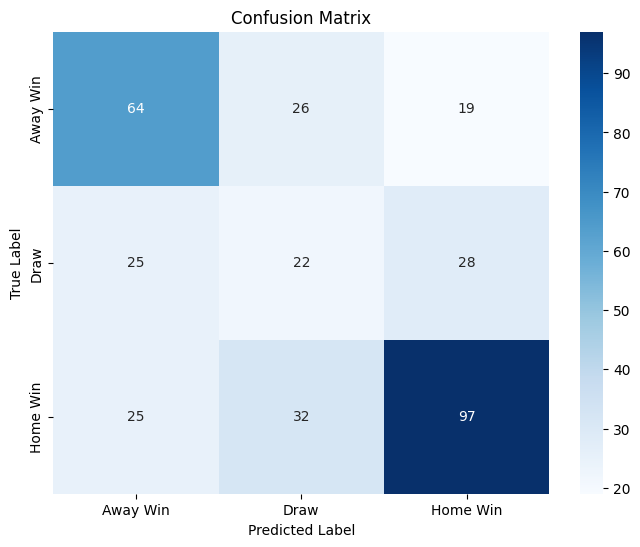

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win']))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'], yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression Classifier
# Using 'liblinear' solver for good performance on small datasets and handling L1/L2 penalties.
# 'class_weight='balanced'' helps address class imbalance.
logistic_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation (Logistic Regression)

Accuracy (Logistic Regression): 0.4379

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Away Win       0.43      0.45      0.44       109
        Draw       0.15      0.08      0.10        75
    Home Win       0.51      0.60      0.55       154

    accuracy                           0.44       338
   macro avg       0.36      0.38      0.36       338
weighted avg       0.40      0.44      0.42       338



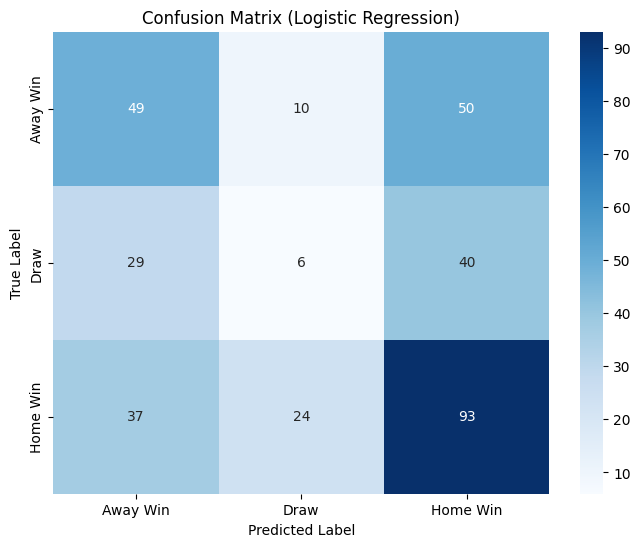

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_lr = logistic_model.predict(X_test)

# Evaluate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (Logistic Regression): {accuracy_lr:.4f}")

# Display classification report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['Away Win', 'Draw', 'Home Win']))

# Display confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'], yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Load Groupstage Matches Data

I will now load the `groupstage.csv` file from the provided Google Drive link into a pandas DataFrame named `groupstage`.

In [50]:
# Install necessary library for Google Drive download
!pip install gdown

import gdown
import pandas as pd

# Google Drive file ID
file_id = '17tamBhkzytToYeOIgvE-LH8h3KS4eoqA'
output_file = 'groupstage.csv'

# Download the file
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, fuzzy=True)

# Load the CSV into a pandas DataFrame
groupstage = pd.read_csv(output_file)

# Display the first 5 rows of the DataFrame
display(groupstage.head())

Downloading...
From: https://drive.google.com/uc?id=17tamBhkzytToYeOIgvE-LH8h3KS4eoqA
To: /content/groupstage.csv
100%|██████████| 6.52k/6.52k [00:00<00:00, 6.48MB/s]


,fixture_id,kickoff_utc,group,matchday,home_code,home_name,away_code,away_name,model_home_pct,model_draw_pct,model_away_pct,favourite_code,actual_home_goals,actual_away_goals,verdict
0,wc-a-md1-mex-rsa,2026-06-11T19:00:00.000Z,A,1,mex,Mexico,rsa,South Africa,88,7,5,mex,NaN,NaN,NaN
1,wc-a-md1-kor-cze,2026-06-12T02:00:00.000Z,A,1,kor,South Korea,cze,Czechia,49,25,26,kor,NaN,NaN,NaN
2,wc-b-md1-can-bih,2026-06-12T19:00:00.000Z,B,1,can,Canada,bih,Bosnia & Herzegovina,79,13,8,can,NaN,NaN,NaN
3,wc-d-md1-usa-par,2026-06-13T01:00:00.000Z,D,1,usa,United States,par,Paraguay,70,17,13,usa,NaN,NaN,NaN
4,wc-b-md1-qat-sui,2026-06-13T19:00:00.000Z,B,1,qat,Qatar,sui,Switzerland,8,13,79,sui,NaN,NaN,NaN


In [61]:
# Make a copy of the groupstage data for feature engineering
df_groupstage_predictions = groupstage.copy()

# Convert 'kickoff_utc' to datetime objects (needed for string formatting later)
df_groupstage_predictions['kickoff_utc'] = pd.to_datetime(df_groupstage_predictions['kickoff_utc'])

# --- Map team codes to full names (from previous feature engineering step) ---
country_code_to_name = {
    'mex': 'Mexico',
    'kor': 'South Korea',
    'cze': 'Czechia',
    'can': 'Canada',
    'bih': 'Bosnia and Herzegovina',
    'qat': 'Qatar',
    'sui': 'Switzerland',
    'bra': 'Brazil',
    'mar': 'Morocco',
    'hai': 'Haiti',
    'sco': 'Scotland',
    'usa': 'United States',
    'par': 'Paraguay',
    'aus': 'Australia',
    'tur': 'Turkey',
    'ger': 'Germany',
    'cur': 'Curacao',
    'civ': 'Ivory Coast',
    'ecu': 'Ecuador',
    'ned': 'Netherlands',
    'jpn': 'Japan',
    'swe': 'Sweden',
    'tun': 'Tunisia',
    'bel': 'Belgium',
    'egy': 'Egypt',
    'irn': 'Iran',
    'nzl': 'New Zealand',
    'esp': 'Spain',
    'cpv': 'Cape Verde',
    'ksa': 'Saudi Arabia',
    'uru': 'Uruguay',
    'fra': 'France',
    'sen': 'Senegal',
    'irq': 'Iraq',
    'nor': 'Norway',
    'arg': 'Argentina',
    'alg': 'Algeria',
    'aut': 'Austria',
    'jor': 'Jordan',
    'por': 'Portugal',
    'cod': 'DR Congo',
    'uzb': 'Uzbekistan',
    'col': 'Colombia',
    'eng': 'England',
    'cro': 'Croatia',
    'gha': 'Ghana',
    'pan': 'Panama'
}

df_groupstage_predictions['home_team_name'] = df_groupstage_predictions['home_code'].map(country_code_to_name).fillna(df_groupstage_predictions['home_code'])
df_groupstage_predictions['away_team_name'] = df_groupstage_predictions['away_code'].map(country_code_to_name).fillna(df_groupstage_predictions['away_code'])

# --- Add Current ELOs (since last WC) ---
elo_df_current = pd.DataFrame.from_dict(elo_ratings, orient='index', columns=['current_elo'])
elo_df_current.index.name = 'team'

df_groupstage_predictions = df_groupstage_predictions.merge(elo_df_current, left_on='home_team_name', right_index=True, how='left')
df_groupstage_predictions = df_groupstage_predictions.rename(columns={'current_elo': 'home_team_elo'})

df_groupstage_predictions = df_groupstage_predictions.merge(elo_df_current, left_on='away_team_name', right_index=True, how='left')
df_groupstage_predictions = df_groupstage_predictions.rename(columns={'current_elo': 'away_team_elo'})

# Fill any missing ELOs with the base 1500
df_groupstage_predictions['home_team_elo'] = df_groupstage_predictions['home_team_elo'].fillna(1500)
df_groupstage_predictions['away_team_elo'] = df_groupstage_predictions['away_team_elo'].fillna(1500)

# Calculate home_win_elo_last4yrs
df_groupstage_predictions['home_win_elo_last4yrs'] = df_groupstage_predictions.apply(
    lambda row: calculate_win_probability(row['home_team_elo'], row['away_team_elo']), axis=1
)

# --- Add Historic ELOs ---
# Merge historic ELOs into df_groupstage_predictions
df_groupstage_predictions = df_groupstage_predictions.merge(
    merged_elo_df[['historic']], left_on='home_team_name', right_index=True, how='left'
).rename(columns={'historic': 'home_team_elo_historic'})

df_groupstage_predictions = df_groupstage_predictions.merge(
    merged_elo_df[['historic']], left_on='away_team_name', right_index=True, how='left'
).rename(columns={'historic': 'away_team_elo_historic'})

# Fill any missing historic ELOs
df_groupstage_predictions['home_team_elo_historic'] = df_groupstage_predictions['home_team_elo_historic'].fillna(1500)
df_groupstage_predictions['away_team_elo_historic'] = df_groupstage_predictions['away_team_elo_historic'].fillna(1500)

# Calculate home_win_elo_historic
df_groupstage_predictions['home_win_elo_historic'] = df_groupstage_predictions.apply(
    lambda row: calculate_win_probability(row['home_team_elo_historic'], row['away_team_elo_historic']), axis=1
)

# --- Prepare features for model predictions (X_groupstage_pred) ---
# Feature: ELO Difference (using current ELO)
df_groupstage_predictions['elo_difference'] = df_groupstage_predictions['home_team_elo'] - df_groupstage_predictions['away_team_elo']

# Feature: Home Advantage (assuming all group stage matches are neutral)
# We set 'is_home_team_home' to 0, indicating no home advantage, as 'neutral' column is not present in groupstage data.
df_groupstage_predictions['is_home_team_home'] = 0

# Feature: Win Streaks (using the team_win_streaks dict from previous steps)
df_groupstage_predictions['home_win_streak'] = df_groupstage_predictions['home_team_name'].map(team_win_streaks).fillna(0)
df_groupstage_predictions['away_win_streak'] = df_groupstage_predictions['away_team_name'].map(team_win_streaks).fillna(0)

# Select the features for prediction, ensuring they match the training features order and names
# The `features` list should be defined from the training section. If not, explicitly list them:
# features = ['home_team_elo', 'away_team_elo', 'elo_difference', 'is_home_team_home', 'home_win_streak', 'away_win_streak']

X_groupstage_pred = df_groupstage_predictions[features]

# --- Add Random Forest predictions ---
# Ensure 'final_model' is defined, falling back to 'model' if tuning was not completed.
if 'best_rf_model' in locals():
    final_model = best_rf_model
else:
    final_model = model

rf_probas = final_model.predict_proba(X_groupstage_pred)
df_groupstage_predictions['home_lose_RF'] = rf_probas[:, 0] # Probability of Away Win (Home Lose)
df_groupstage_predictions['tie_RF'] = rf_probas[:, 1]     # Probability of Draw
df_groupstage_predictions['home_win_RF'] = rf_probas[:, 2] # Probability of Home Win

# --- Add Logistic Regression predictions ---
lr_probas = logistic_model.predict_proba(X_groupstage_pred)
df_groupstage_predictions['home_lose_LR'] = lr_probas[:, 0] # Probability of Away Win (Home Lose)
df_groupstage_predictions['tie_LR'] = lr_probas[:, 1]     # Probability of Draw
df_groupstage_predictions['home_win_LR'] = lr_probas[:, 2] # Probability of Home Win

# --- Drop requested columns ---
columns_to_drop = [
    'fixture_id', 'group', 'matchday', 'home_code', 'away_code', 'favourite_code',
    'actual_home_goals', 'actual_away_goals', 'verdict', 'is_home_team_home',
    'home_win_streak', 'away_win_streak', 'home_team_name', 'away_team_name'
]
df_groupstage_predictions = df_groupstage_predictions.drop(columns=columns_to_drop, errors='ignore')

# --- Rename columns ---
df_groupstage_predictions = df_groupstage_predictions.rename(columns={
    'home_team_elo': 'home_elo_last4yrs',
    'away_team_elo': 'away_elo_last4yrs',
    'home_team_elo_historic': 'home_elo_historic',
    'away_team_elo_historic': 'away_elo_historic'
})

# --- Format kickoff_utc as date DDMMYYYY ---
df_groupstage_predictions['kickoff_utc'] = df_groupstage_predictions['kickoff_utc'].dt.strftime('%d%m%Y')

print("New probability columns added, specified columns dropped, and kickoff_utc formatted successfully.")
display(df_groupstage_predictions.head())

New probability columns added, specified columns dropped, and kickoff_utc formatted successfully.


,kickoff_utc,home_name,away_name,model_home_pct,model_draw_pct,model_away_pct,home_elo_last4yrs,away_elo_last4yrs,home_win_elo_last4yrs,home_elo_historic,away_elo_historic,home_win_elo_historic,elo_difference,home_lose_RF,tie_RF,home_win_RF,home_lose_LR,tie_LR,home_win_LR
0,11062026,Mexico,South Africa,88,7,5,1563.072275,1500.000000,0.589784,1835.0,1500.0,0.873074,63.072275,0.000000,0.815771,0.184229,0.347422,0.396702,0.255875
1,12062026,South Korea,Czechia,49,25,26,1532.364785,1500.000000,0.546442,1500.0,1731.0,0.209202,32.364785,0.026065,0.534526,0.439409,0.375682,0.393440,0.230878
2,12062026,Canada,Bosnia & Herzegovina,79,13,8,1479.338856,1426.274388,0.575778,1802.0,1500.0,0.850490,53.064468,0.613706,0.353865,0.032429,0.353260,0.392314,0.254426
3,13062026,United States,Paraguay,70,17,13,1494.476117,1464.524827,0.542997,1500.0,1833.0,0.128207,29.951290,0.230780,0.548511,0.220709,0.376182,0.391615,0.232203
4,13062026,Qatar,Switzerland,8,13,79,1454.565790,1504.780084,0.428235,1427.0,1897.0,0.062647,-50.214294,0.720798,0.263770,0.015433,0.448727,0.380676,0.170597


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from weasyprint import HTML
import os

# --- 1. Prepare Model Explanations ---
model_explanations_html = """
<h2>Model Explanations</h2>
<p><b>ELO (Since Last World Cup):</b> This model uses ELO ratings calculated from international match results since the last World Cup (November 2022). It predicts the probability of a home team winning based on the difference in current ELO ratings between the two teams.</p>
<p><b>ELO (Historic):</b> Similar to the above, but based on long-term historic ELO ratings, providing a broader view of team strength over time. It predicts win probabilities based on these established historic ratings.</p>
<p><b>Random Forest Classifier:</b> A powerful ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is trained on ELO differences, home advantage, and win streaks to predict home win, draw, or away win probabilities.</p>
<p><b>Logistic Regression:</b> A linear model used for predicting the probability of a binary or multi-class outcome. Despite its name, it is a classification algorithm. It uses a logistic function to model the probability of a match outcome (home win, draw, or away win) based on the input features like ELO differences and win streaks.</p>
"""

# --- 2. Generate and Save Confusion Matrices as Images ---

def save_confusion_matrix(conf_matrix, title, filename):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Away Win', 'Draw', 'Home Win'], yticklabels=['Away Win', 'Draw', 'Home Win'])
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close() # Close the plot to free memory
    return os.path.abspath(filename) # Return absolute path

# Save Random Forest Confusion Matrix
rf_cm_filename_abs = save_confusion_matrix(conf_matrix, 'Confusion Matrix (Random Forest)', 'rf_confusion_matrix.png')

# Save Logistic Regression Confusion Matrix
lr_cm_filename_abs = save_confusion_matrix(conf_matrix_lr, 'Confusion Matrix (Logistic Regression)', 'lr_confusion_matrix.png')

confusion_matrices_html = f"""
<h2>Model Performance: Confusion Matrices</h2>
<h3>Random Forest Classifier</h3>
<img src="file://{rf_cm_filename_abs}" alt="Random Forest Confusion Matrix" style="width:100%; max-width:600px;">
<h3>Logistic Regression</h3>
<img src="file://{lr_cm_filename_abs}" alt="Logistic Regression Confusion Matrix" style="width:100%; max-width:600px;">
"""

# --- 3. Convert df_groupstage_predictions to HTML ---
df_predictions_html = df_groupstage_predictions.to_html(index=False, float_format='%.2f')
predictions_table_html = f"""
<h2>World Cup Group Stage Predictions</h2>
<p>This table presents the enriched group stage match data, including ELO-based probabilities and model predictions from both the Random Forest and Logistic Regression classifiers. The 'home_win_RF', 'tie_RF', and 'home_lose_RF' columns represent the probabilities for a home win, draw, or home loss (away win) as predicted by the Random Forest model, respectively. Similarly, 'home_win_LR', 'tie_LR', and 'home_lose_LR' represent the probabilities from the Logistic Regression model.</p>
{df_predictions_html}
"""

# --- 4. Combine all HTML content and generate PDF ---
full_html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>WC Groupstage Predictions</title>
    <style>
        @page {{ size: A4 landscape; margin: 2cm; }}
        body {{ font-family: Arial, sans-serif; line-height: 1.6; color: #333; }}
        h1 {{ text-align: center; color: #0056b3; margin-bottom: 30px; }}
        h2 {{ color: #0056b3; border-bottom: 2px solid #eee; padding-bottom: 5px; margin-top: 30px; }}
        h3 {{ color: #0056b3; margin-top: 20px; }}
        p {{ margin-bottom: 10px; text-align: justify; }}
        table {{ width: 100%; border-collapse: collapse; margin-top: 20px; font-size: 0.6em; table-layout: fixed; word-wrap: break-word;}}
        th, td {{ border: 1px solid #ddd; padding: 2px; text-align: left; vertical-align: top; }}
        /* The following lines were causing the bold borders and have been removed as per user request */
        /* th:nth-child(16), td:nth-child(16) {{ */
        /*     border-left: 2px solid #000 !important; */
        /* }} */
        /* th:nth-child(19), td:nth-child(19) {{ */
        /*     border-left: 2px solid #000 !important; */
        /* }} */
        th {{ background-color: #f2f2f2; font-weight: bold; }}
        img {{ display: block; margin: 20px auto; border: 1px solid #ddd; padding: 5px; background-color: #fff; }}
        .page-break {{ page-break-before: always; }}
    </style>
</head>
<body>
    <h1>WC Groupstage Predictions</h1>
    {model_explanations_html}
    <div class="page-break"></div>
    {confusion_matrices_html}
    <div class="page-break"></div>
    {predictions_table_html}
</body>
</html>
"""

# Write the HTML content to a PDF file
HTML(string=full_html_content).write_pdf('wc_groupstage_predictions.pdf')

print("PDF 'wc_groupstage_predictions.pdf' generated successfully.")

# Clean up temporary image files
os.remove('rf_confusion_matrix.png')
os.remove('lr_confusion_matrix.png')

PDF 'wc_groupstage_predictions.pdf' generated successfully.
